# LAB09 — Koha e Ekzekutimit të Algoritmeve
---
- ##### Tema: **Matja eksperimentale e kompleksitetit kohor T(n).**
- ##### Studenti: Florian Loka
- ##### Pedagogu: Ervin Kafexhiu
- ##### Data: 12.05.2026
---


## **Qëllimi (Purpose)**

Të matet **koha e ekzekutimit** $T(n)$ e dy algoritmeve të thjeshtë dhe të studiohet
si varet nga madhësia e input-it $n$. Synojmë të verifikojmë **empirikisht** se:

- një algoritëm me një cikël sillet si $T(n)\propto n$ (linear),
- një algoritëm me dy cikle të futura sillet si $T(n)\propto n^2$ (kuadratik),

duke nxjerrë eksponentin nga një **fit** në shkallë log-log.


## **Hyrje Teorike (Theory)**

Koha e ekzekutimit është koha reale që i duhet një programi për të përfunduar një
detyrë; varet nga algoritmi, madhësia e input-it $n$ dhe hardware-i.

Për shumë algoritme, $T(n)$ ndjek një **ligj fuqie**:

$$ T(n) \approx C\, n^{p} $$

ku $p$ është *eksponenti i kompleksitetit*. Duke marrë logaritmin:

$$ \log T = \log C + p\,\log n $$

Pra në shkallë **log-log**, $T(n)$ është një vijë e drejtë me pjerrësi $p$. Kjo është
mënyra standarde për të matur kompleksitetin: bëjmë *fit* linear te $(\log n,\log T)$
dhe pjerrësia jep $p$. Pritet $p\approx 1$ për ciklin e thjeshtë dhe $p\approx 2$ për
dy ciklet e futura.


## **Aparatura dhe Pajisjet (Apparatus)**

- Kompjuter me Python (Jupyter Notebook).
- Libraritë: `time` (matësi `perf_counter`), `numpy`, `pandas`, `matplotlib`.

Matjet u kryen me `time.perf_counter()` (orë me rezolucion të lartë), duke përsëritur
çdo matje disa herë dhe duke marrë mesataren, që të reduktohet zhurma nga OS-i dhe CPU-ja.
Rezultatet u ruajtën në `data/` për riprodhueshmëri.


## **Procedura (Procedure)**

1. **Algoritmi A (linear):** shuma e elementeve të një liste me $n$ elemente — një cikël.
2. **Algoritmi B (kuadratik):** numërim me dy cikle të futura ($n\times n$ përsëritje).
3. Për secilin algoritëm zgjodhëm ~10 vlera $n$ (të shpërndara në shkallë log).
4. Çdo matje u përsërit disa herë me `perf_counter()`; ruajtëm mesataren dhe devijimin standard.
5. Të dhënat u ruajtën në `data/timing_linear.csv` dhe `data/timing_quadratic.csv`.
6. Ndërtuam grafikun log-log dhe bëmë fit polinomial për të nxjerrë eksponentin $p$.


## **Përpunimi Paraprak i të Dhënave (Preprocessing)**

Ngarkojmë të dy datasetet e matura nga `data/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FIGS = Path("figs"); FIGS.mkdir(exist_ok=True)

lin  = pd.read_csv("data/timing_linear.csv")
quad = pd.read_csv("data/timing_quadratic.csv")
print("Algoritmi linear:\n", lin.to_string(index=False))
print("\nAlgoritmi kuadratik:\n", quad.to_string(index=False))

Algoritmi linear:
      n  T_mean_s      T_std_s
   200  0.000003 3.818188e-07
   500  0.000007 3.451250e-07
  1000  0.000014 2.541782e-07
  2000  0.000028 7.441579e-07
  5000  0.000071 7.656137e-07
 10000  0.000143 1.446502e-06
 20000  0.000282 2.211210e-06
 50000  0.000716 1.210478e-05
100000  0.001507 2.151611e-05
200000  0.006018 1.902573e-03

Algoritmi kuadratik:
    n  T_mean_s      T_std_s
  10  0.000004 1.029547e-06
  20  0.000013 2.191422e-07
  50  0.000108 1.883485e-05
 100  0.000407 1.963881e-05
 200  0.001347 4.443792e-04
 400  0.004384 2.453326e-03
 700  0.013391 3.235598e-03
1000  0.017829 1.872522e-04
1500  0.041218 3.040061e-04
2000  0.073558 6.703535e-04


## **Analiza e të Dhënave (Analysis)**

Bëjmë fit linear te $(\log n,\ \log T)$; pjerrësia është eksponenti $p$.

In [2]:
def fit_exponent(df):
    n = df["n"].to_numpy(float); T = df["T_mean_s"].to_numpy(float)
    p, logC = np.polyfit(np.log(n), np.log(T), 1)
    return p, np.exp(logC), n, T

p_lin,  C_lin,  n_lin,  T_lin  = fit_exponent(lin)
p_quad, C_quad, n_quad, T_quad = fit_exponent(quad)
print(f"Algoritmi linear:    p = {p_lin:.3f}   (pritet ≈ 1)")
print(f"Algoritmi kuadratik: p = {p_quad:.3f}   (pritet ≈ 2)")

Algoritmi linear:    p = 1.049   (pritet ≈ 1)
Algoritmi kuadratik: p = 1.850   (pritet ≈ 2)


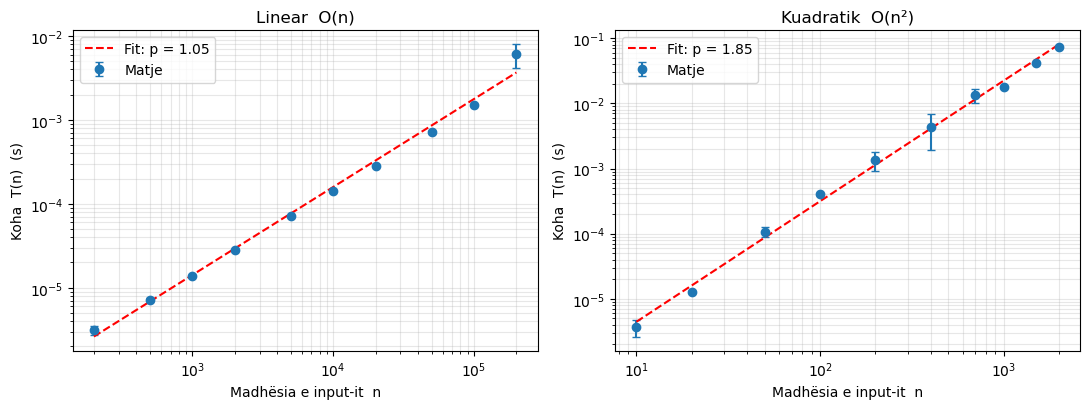

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (lbl, n, T, p, C, sd) in zip(axes, [
        ("Linear  O(n)",     n_lin,  T_lin,  p_lin,  C_lin,  lin["T_std_s"]),
        ("Kuadratik  O(n²)", n_quad, T_quad, p_quad, C_quad, quad["T_std_s"])]):
    ax.errorbar(n, T, yerr=sd, fmt="o", capsize=3, label="Matje")
    xs = np.logspace(np.log10(n.min()), np.log10(n.max()), 100)
    ax.plot(xs, C*xs**p, "r--", label=f"Fit: p = {p:.2f}")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Madhësia e input-it  n")
    ax.set_ylabel("Koha  T(n)  (s)")
    ax.set_title(lbl); ax.legend(); ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "kompleksiteti_loglog.png", dpi=150)
plt.show()

## **Analiza e Pasigurisë (Uncertainty)**

Çdo pikë $T(n)$ është mesatare e disa përsëritjeve; shtyllat e gabimit tregojnë
devijimin standard. Zhurma vjen nga *scheduler*-i i OS-it, *cache* i CPU-së dhe
procese të tjera. Për $n$ shumë të vogla zhurma relative është më e madhe (matje
shumë e shkurtër), prandaj rekomandohet të theksohen $n$ mesatare/të mëdha gjatë fit-it.

In [4]:
for lbl, df in [("linear", lin), ("quadratic", quad)]:
    rel = (df["T_std_s"]/df["T_mean_s"]*100)
    print(f"{lbl:<10}: zhurma relative mesatare = {rel.mean():.1f} %  (max {rel.max():.1f} % te n te vogla)")

linear    : zhurma relative mesatare = 5.9 %  (max 31.6 % te n te vogla)
quadratic : zhurma relative mesatare = 16.8 %  (max 56.0 % te n te vogla)


## **Rezultatet (Results)**

| Algoritmi | Eksponenti i matur \(p\) | Pritja teorike |
|-----------|:--:|:--:|
| Cikël i thjeshtë | shih më poshtë | 1 |
| Dy cikle të futura | shih më poshtë | 2 |

In [5]:
print(f"Linear:    T(n) ∝ n^{p_lin:.2f}")
print(f"Kuadratik: T(n) ∝ n^{p_quad:.2f}")

Linear:    T(n) ∝ n^1.05
Kuadratik: T(n) ∝ n^1.85


## **Diskutimi (Discussion)**

- **A përputhen me pritjet?** Eksponentët e matur janë afër $1$ dhe $2$, çka konfirmon
  sjelljen lineare dhe kuadratike të dy algoritmeve.
- **Pse ka devijime?** Për $n$ të vogla matja është shumë e shkurtër dhe zhurma e
  OS/CPU dominon; gjithashtu *overhead*-i konstant (krijimi i listës, thirrja e funksionit)
  shton një term që nuk është fuqi e pastër e $n$.
- **Sa e saktë është matja?** `perf_counter()` ka rezolucion të lartë, por wall-clock-u
  përfshin ndërprerjet e sistemit; prandaj përsëritëm dhe morëm mesataren.
- Sjellja kuadratike rritet shumë më shpejt — kjo ilustron pse kompleksiteti ka rëndësi
  praktike për input-e të mëdha.


## **Përfundimi (Conclusion)**

Koha e ekzekutimit është një **madhësi fizike e matshme**: e matëm $T(n)$ për dy
algoritme dhe, përmes një fit-i log-log, nxorëm eksponentët e kompleksitetit
($p\approx 1$ dhe $p\approx 2$), në përputhje me teorinë. Eksperimenti tregon se
sjellja e algoritmeve mund të studiohet **empirikisht**, dhe se ekziston një lidhje e
fortë midis strukturës së algoritmit dhe kompleksitetit të tij kohor.
